# Heat Equation on a Graph

## Setup

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

## Graph

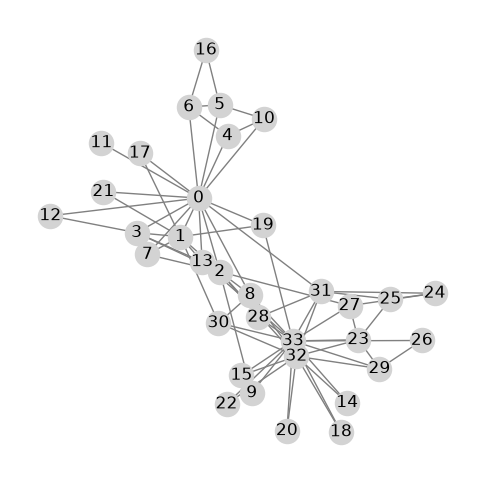

In [2]:
G = nx.karate_club_graph()
pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(6, 6))
nx.draw(G, pos, ax=ax, node_color="lightgray", edge_color="gray", with_labels=True)
plt.show()

## Laplacian & Initial Condition

In [3]:
adjacency = nx.to_numpy_array(G)
degree = np.diag(adjacency.sum(axis=1))
L = degree - adjacency
n = L.shape[0]

u0 = np.zeros(n)
u0[0] = 1.0

dt = 0.02
n_steps = 300

## Finite Difference Time-Stepping (Crank–Nicolson)

In [4]:
I = np.eye(n)
A = I + (dt / 2) * L
B = I - (dt / 2) * L

history = np.zeros((n_steps + 1, n))
history[0] = u0

u = u0.copy()
for k in range(n_steps):
    u = np.linalg.solve(A, B @ u)
    history[k + 1] = u

## Graph Snapshots Over Time

It looks like it diffuses very quickly. I think that this is a function of the connectivity of the graph. I will investigate further.

There is an additional question about the edges and whether we need to model their diffusivity as well. In this model the nodes are all equally spaced, i.e. they are a unit distance apart (as described by the Laplacian). We can change that by creating a weighted laplacian.

I have a suspicion that for the paper, the graph is not so much a graph in this adjacency sense as in some specific geometric structure, as we can see from the plots.

The nodes have some properties, but the edges themselves take up physical space and would be modelled.

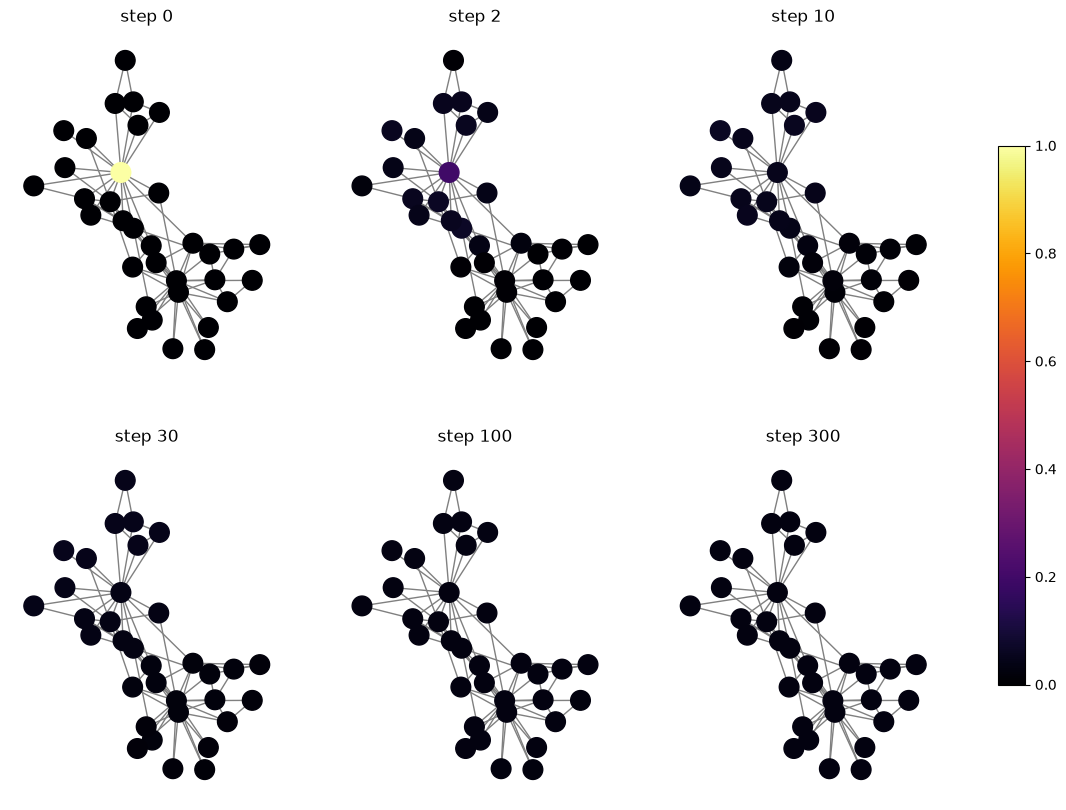

In [5]:
snapshot_steps = [0, 2, 10, 30, 100, 300]
vmin, vmax = history.min(), history.max()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, step in zip(axes.flat, snapshot_steps):
    nx.draw(
        G, pos, ax=ax,
        node_color=history[step],
        cmap="inferno", vmin=vmin, vmax=vmax,
        edge_color="gray", with_labels=False, node_size=200,
    )
    ax.set_title(f"step {step}")

sm = plt.cm.ScalarMappable(cmap="inferno", norm=plt.Normalize(vmin=vmin, vmax=vmax))
fig.colorbar(sm, ax=axes, shrink=0.7)
plt.show()

## Node Values Over Time

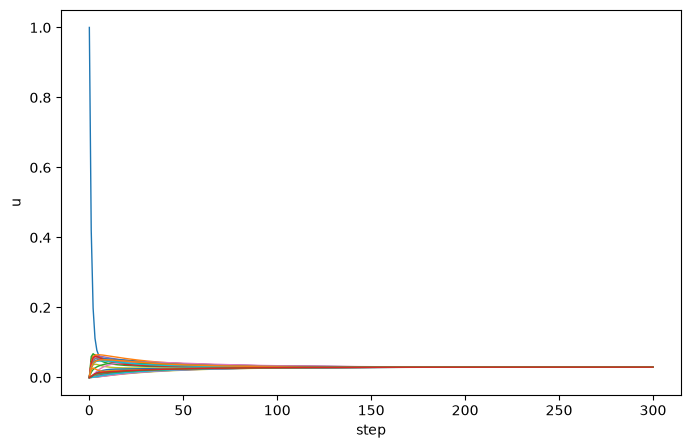

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for node in range(n):
    ax.plot(history[:, node], linewidth=1)
ax.set_xlabel("step")
ax.set_ylabel("u")
plt.show()